In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("ecommerce_sales_eda_practice.csv")

In [3]:
df.head()

,Order_ID,Order_Date,City,Category,Product,Customer_Age,Unit_Price,Quantity,Discount_Percent,Total_Sales,Payment_Method,Delivery_Days,Customer_Rating
0,ORD00149,2025-01-15,Mumbai,Clothing,Jacket,63.0,1232.0,1,10,1108.80,UPI,5.0,4.5
1,ORD00479,2025-06-23,Pune,Home,Bottle,62.0,99000.0,5,20,396000.00,UPI,6.0,4.4
2,ORD00050,2025-04-10,Kolkata,Electronics,Smartwatch,46.0,2867.0,3,5,8170.95,UPI,5.0,4.3
3,ORD00208,2025-01-20,Dehradun,Beauty,Cream,38.0,728.0,4,10,2620.80,UPI,7.0,3.4
4,ORD00477,2025-05-26,Bengaluru,Clothing,T-Shirt,34.0,716.0,2,0,1432.00,Card,6.0,4.4


In [4]:
df.shape

(605, 13)

In [5]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 605 entries, 0 to 604
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Order_ID          605 non-null    object 
 1   Order_Date        605 non-null    object 
 2   City              605 non-null    object 
 3   Category          605 non-null    object 
 4   Product           605 non-null    object 
 5   Customer_Age      578 non-null    float64
 6   Unit_Price        605 non-null    float64
 7   Quantity          605 non-null    int64  
 8   Discount_Percent  605 non-null    int64  
 9   Total_Sales       605 non-null    float64
 10  Payment_Method    587 non-null    object 
 11  Delivery_Days     592 non-null    float64
 12  Customer_Rating   569 non-null    float64
dtypes: float64(5), int64(2), object(6)
memory usage: 61.6+ KB


In [6]:
df.describe()

,Customer_Age,Unit_Price,Quantity,Discount_Percent,Total_Sales,Delivery_Days,Customer_Rating
count,578.000000,605.000000,605.000000,605.000000,605.000000,592.000000,569.000000
mean,42.512111,1809.920661,2.986777,9.578512,4649.543802,4.082770,3.996134
std,13.729146,5364.853358,1.404754,8.124397,16739.223717,1.731046,0.635831
min,18.000000,120.000000,1.000000,0.000000,108.000000,1.000000,2.000000
25%,31.000000,716.000000,2.000000,5.000000,1533.000000,3.000000,3.500000
50%,43.000000,1202.000000,3.000000,10.000000,2901.600000,4.000000,4.000000
75%,55.000000,1954.000000,4.000000,15.000000,5061.000000,5.000000,4.500000
max,65.000000,99000.000000,5.000000,30.000000,396000.000000,10.000000,5.000000


In [7]:
df.isnull().sum()

Order_ID             0
Order_Date           0
City                 0
Category             0
Product              0
Customer_Age        27
Unit_Price           0
Quantity             0
Discount_Percent     0
Total_Sales          0
Payment_Method      18
Delivery_Days       13
Customer_Rating     36
dtype: int64

In [8]:
df["Quantity"].unique()

array([1, 5, 3, 4, 2])

In [9]:
df[df.duplicated()]

,Order_ID,Order_Date,City,Category,Product,Customer_Age,Unit_Price,Quantity,Discount_Percent,Total_Sales,Payment_Method,Delivery_Days,Customer_Rating
460,ORD00205,2025-05-26,Patna,Electronics,Headphones,60.0,1962.0,4,0,7848.00,Cash on Delivery,5.0,5.0
480,ORD00016,2025-04-21,Patna,Electronics,Headphones,23.0,1224.0,2,10,2203.20,Card,5.0,3.8
527,ORD00559,2025-10-24,Bengaluru,Home,Chair,53.0,1435.0,5,5,6816.25,UPI,1.0,3.8
539,ORD00073,2025-09-16,Pune,Sports,Racket,34.0,1612.0,2,10,2901.60,Card,NaN,3.2
589,ORD00412,2025-05-26,Hyderabad,Beauty,Face Wash,55.0,583.0,5,5,2769.25,UPI,2.0,NaN


In [10]:
df.duplicated().sum()

np.int64(5)

In [11]:
df.drop_duplicates(inplace=True)

In [12]:
df.shape

(600, 13)

In [13]:
### outliers

Unit_Price = df["Unit_Price"]
Unit_Price

0       1232.0
1      99000.0
2       2867.0
3        728.0
4        716.0
        ...   
600      336.0
601     2241.0
602      464.0
603      797.0
604      787.0
Name: Unit_Price, Length: 600, dtype: float64

In [14]:
Q1 = df["Unit_Price"].quantile(0.25)
Q3 = df["Unit_Price"].quantile(0.50)


In [15]:
Q1

np.float64(715.5)

In [16]:
Q3

np.float64(1195.5)

In [17]:
## calculate IQR

IQR = Q3 - Q1

In [18]:
IQR

np.float64(480.0)

In [19]:
lower_fence = Q1 - 1.5 * IQR
upper_fence = Q3 + 1.5 * IQR

In [20]:
lower_fence


np.float64(-4.5)

In [21]:
upper_fence

np.float64(1915.5)

In [22]:
### Find outliers in Unit_Price

outliers = df[
    (df["Unit_Price"] < lower_fence) |
    (df["Unit_Price"] > upper_fence)
]




In [23]:
print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Fence :", lower_fence)
print("Upper Fence :", upper_fence)
print("Total Outliers :", len(outliers))

Q1: 715.5
Q3: 1195.5
IQR: 480.0
Lower Fence : -4.5
Upper Fence : 1915.5
Total Outliers : 163


In [24]:
display(outliers)

,Order_ID,Order_Date,City,Category,Product,Customer_Age,Unit_Price,Quantity,Discount_Percent,Total_Sales,Payment_Method,Delivery_Days,Customer_Rating
1,ORD00479,2025-06-23,Pune,Home,Bottle,62.0,99000.0,5,20,396000.00,UPI,6.0,4.4
2,ORD00050,2025-04-10,Kolkata,Electronics,Smartwatch,46.0,2867.0,3,5,8170.95,UPI,5.0,4.3
12,ORD00437,2025-01-21,Hyderabad,Electronics,Headphones,52.0,1940.0,3,5,5529.00,Card,3.0,3.6
16,ORD00196,2025-02-26,Hyderabad,Electronics,Keyboard,20.0,3875.0,2,10,6975.00,UPI,4.0,4.4
21,ORD00413,2025-06-03,Pune,Electronics,Keyboard,NaN,3996.0,4,5,15184.80,Cash on Delivery,4.0,3.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...
593,ORD00502,2025-12-09,Delhi,Sports,Yoga Mat,23.0,2343.0,5,20,9372.00,Card,3.0,5.0
594,ORD00038,2025-06-19,Patna,Home,Lamp,21.0,2661.0,2,10,4789.80,UPI,3.0,3.0
596,ORD00547,2025-06-04,Mumbai,Clothing,Shoes,45.0,2378.0,3,10,6420.60,Net Banking,5.0,3.2
598,ORD00417,2025-08-07,Delhi,Electronics,Smartwatch,32.0,2268.0,2,20,3628.80,UPI,5.0,NaN


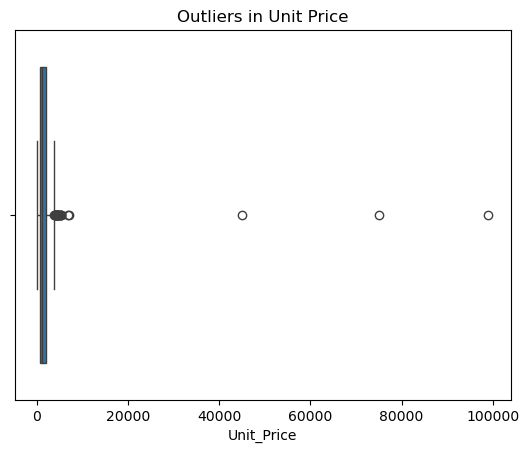

In [25]:
### for visualization

sns.boxplot(x=df["Unit_Price"])
plt.title("Outliers in Unit Price")
plt.show()

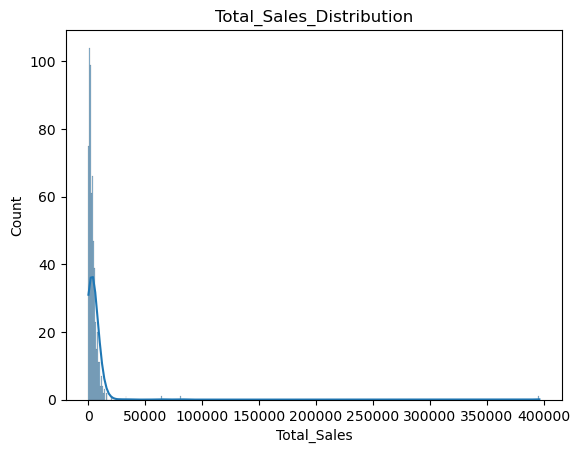

In [26]:
## Plot the distribution of Total_Sales using a histogram

sns.histplot(df["Total_Sales"], kde = True)
plt.title("Total_Sales_Distribution")
plt.show()

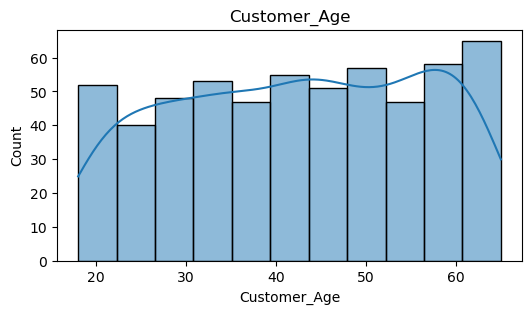

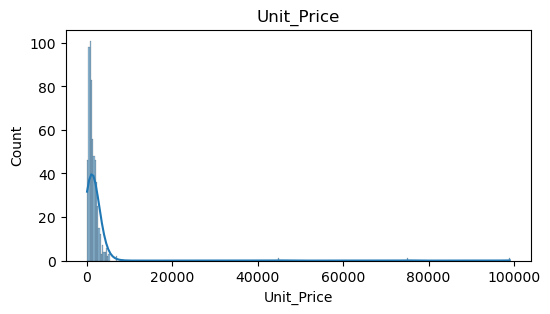

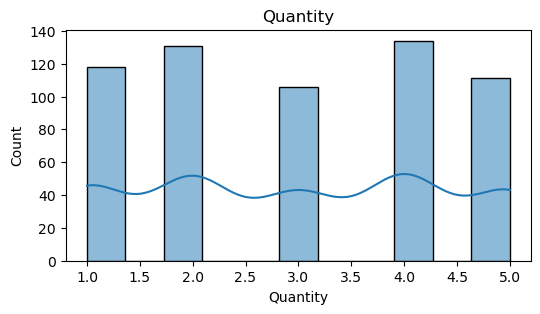

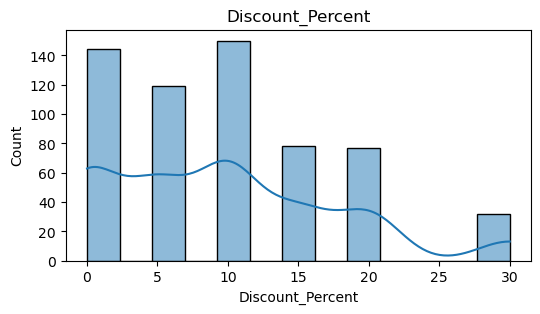

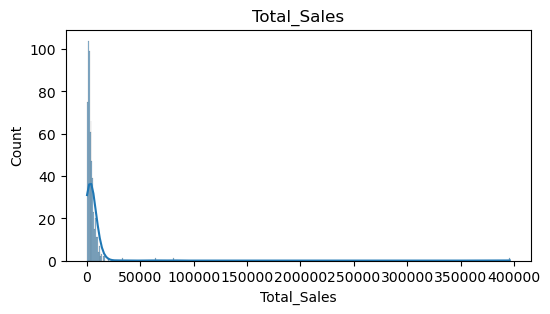

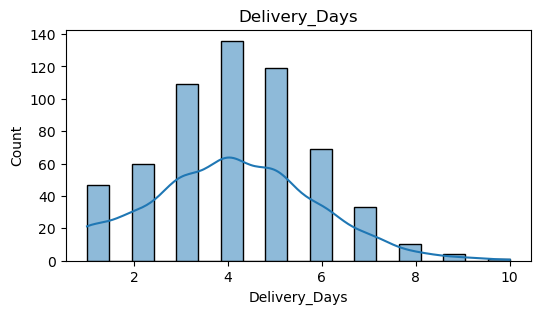

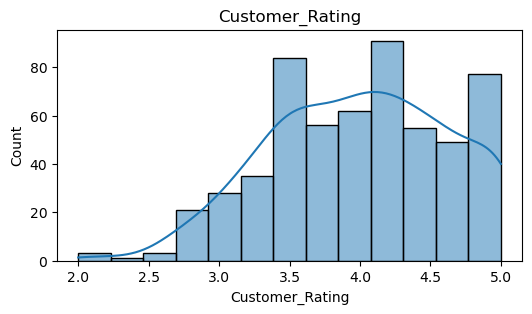

In [27]:
## Analyze each feature separately

for col in df.select_dtypes(include="number").columns:
    plt.figure(figsize = (6, 3))
    sns.histplot(df[col],kde=True)
    plt.title(col)
    plt.show()

####  Find which product category has the highest total sales. ?

In [ ]:


category_sales = df.groupby("Category")["Total_Sales"].sum()
print(category_sales)

Category
Beauty         179576.5
Books          159885.4
Clothing       459348.1
Electronics    904001.1
Home           843794.2
Sports         243830.4
Name: Total_Sales, dtype: float64


In [29]:
### Sort from highest to lowest 

category_sales = df.groupby("Category")["Total_Sales"].sum().sort_values(ascending=False)
print(category_sales)

Category
Electronics    904001.1
Home           843794.2
Clothing       459348.1
Sports         243830.4
Beauty         179576.5
Books          159885.4
Name: Total_Sales, dtype: float64


In [31]:
## Find only the winning category

print("Highest Sales  Category:",category_sales.idxmax())
print("Total Sales:",category_sales.max())

Highest Sales  Category: Electronics
Total Sales: 904001.1


In [35]:
## Find the five cities generating the highest sales.

df.head()


,Order_ID,Order_Date,City,Category,Product,Customer_Age,Unit_Price,Quantity,Discount_Percent,Total_Sales,Payment_Method,Delivery_Days,Customer_Rating
0,ORD00149,2025-01-15,Mumbai,Clothing,Jacket,63.0,1232.0,1,10,1108.80,UPI,5.0,4.5
1,ORD00479,2025-06-23,Pune,Home,Bottle,62.0,99000.0,5,20,396000.00,UPI,6.0,4.4
2,ORD00050,2025-04-10,Kolkata,Electronics,Smartwatch,46.0,2867.0,3,5,8170.95,UPI,5.0,4.3
3,ORD00208,2025-01-20,Dehradun,Beauty,Cream,38.0,728.0,4,10,2620.80,UPI,7.0,3.4
4,ORD00477,2025-05-26,Bengaluru,Clothing,T-Shirt,34.0,716.0,2,0,1432.00,Card,6.0,4.4


In [41]:
top_5_cities = df.groupby("City")["Total_Sales"].sum().sort_values(ascending=False).head(5)
print(top_5_cities)

City
Pune         686605.65
Hyderabad    407430.15
Mumbai       361951.75
Delhi        296028.40
Kolkata      287534.80
Name: Total_Sales, dtype: float64


#####  Compare average Customer_Rating by category.

In [ ]:


category_rating = df.groupby("Category")["Customer_Rating"].mean().sort_values(ascending=False)
print(category_rating)

Category
Beauty         4.091139
Electronics    4.028358
Sports         3.981429
Home           3.966364
Clothing       3.955932
Books          3.948148
Name: Customer_Rating, dtype: float64


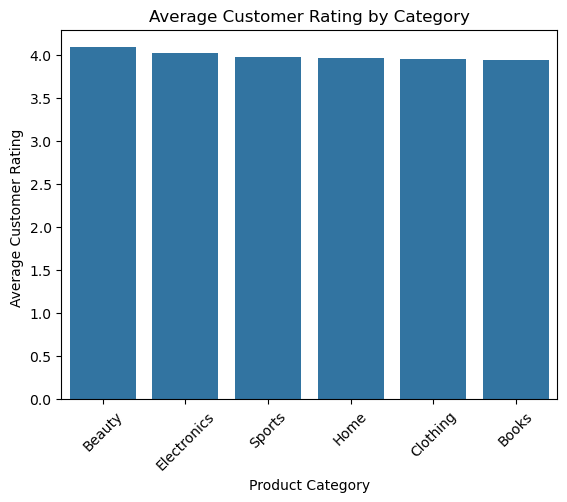

In [44]:
### Visualize it using Seaborn

import matplotlib.pyplot as plt
import seaborn as sns

sns.barplot(
    x=category_rating.index,
    y=category_rating.values
)

plt.xlabel("Product Category")
plt.ylabel("Average Customer Rating ")
plt.title("Average Customer Rating by Category")
plt.xticks(rotation=45)
plt.show()